In [19]:
import requests
import base64
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

In [20]:
# Load and send image
image_path = "/Users/jesseleung/Projects/tnc-projects/animl/animl-ml/models/megadetectorv1000/test_letterbox.jpg"  # Update this

with open(image_path, "rb") as f:
    image_bytes = f.read()

response = requests.post(
    "http://localhost:8080/invocations",
    data=base64.b64encode(image_bytes)
)

result = response.json()
print(result)
detections = result[0]  # Extract detections from [[...]] format

[[{'x1': 0.3705, 'y1': 0.0032, 'x2': 0.7586999999999999, 'y2': 0.8425, 'confidence': 0.009, 'class': 2}, {'x1': 0.188, 'y1': 0.6101, 'x2': 0.3398, 'y2': 0.8401, 'confidence': 0.894, 'class': 1}]]


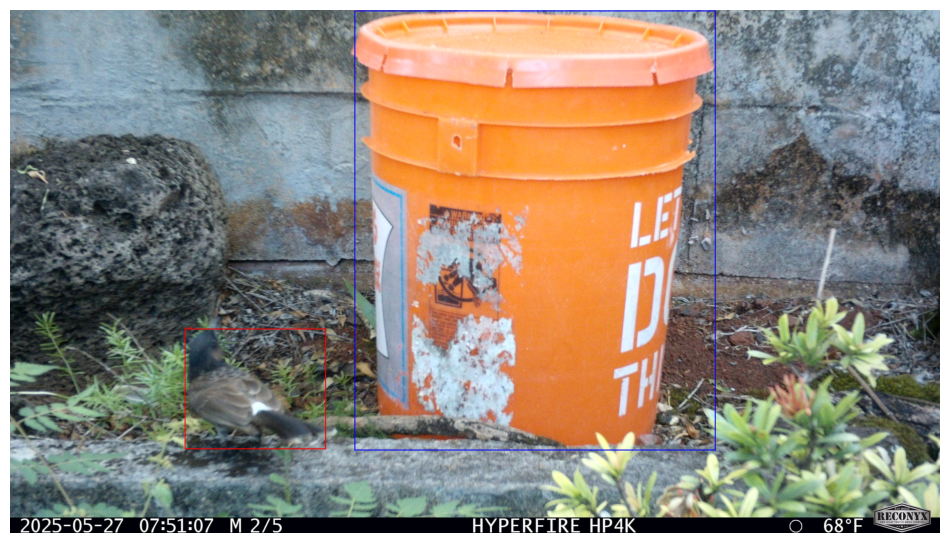

In [21]:
# Draw detections
image = Image.open(image_path)
draw = ImageDraw.Draw(image)
w, h = image.size
color_map = { 1: 'red', 2: 'blue', 3: 'yellow' }

for det in detections:
    o_col = color_map.get(int(det["class"]))
    x1, y1 = det["x1"] * w, det["y1"] * h
    x2, y2 = det["x2"] * w, det["y2"] * h
    
    draw.rectangle([x1, y1, x2, y2], outline=o_col, width=4)
    draw.text((x1, y1 - 10), f"{det['class']}: {det['confidence']:.2f}", fill="red")

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.show()